# Sprint 4 - Classical Machine Learning Benchmark

**Project:** AutoGuard AI - Insurance Underwriting Assistant  
**Scope:** classical machine-learning benchmarking only  
**Frozen dataset version:** `data/processed/sprint_03_preprocessed_v1/`  
**Target:** `is_claim`

This notebook uses the approved Sprint 3 exports exactly as provided. It benchmarks Logistic Regression, Decision Tree, Random Forest, and XGBoost when available, then stops before any PyTorch or Sprint 5 work.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from ml_pipeline import ml_engineer as eng

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [2]:
dataset = eng.load_benchmark_dataset()
benchmark_results = eng.run_classical_benchmark(dataset)
holdout_comparison = eng.model_comparison_table(benchmark_results, split='holdout')
validation_comparison = eng.model_comparison_table(benchmark_results, split='validation')

print('Train shape:', dataset.X_train.shape)
print('Validation shape:', dataset.X_validation.shape)
print('Holdout shape:', dataset.X_holdout.shape)
print('XGBoost available:', eng.XGBOOST_AVAILABLE)

Train shape: (41015, 61)
Validation shape: (8789, 61)
Holdout shape: (8788, 61)
XGBoost available: False


In [3]:
def metrics_frame(result):
    return pd.DataFrame([
        {'split': 'validation', **result['validation_evaluation']['metrics']},
        {'split': 'holdout', **result['holdout_evaluation']['metrics']},
    ])

def plot_result_diagnostics(result, title_prefix):
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for row_index, split_name in enumerate(['validation', 'holdout']):
        evaluation = result[f'{split_name}_evaluation']
        eng.plot_confusion_matrix(evaluation['confusion_matrix'], axes[row_index, 0], f'{title_prefix} - {split_name} confusion')
        eng.plot_roc_curve(evaluation['roc_curve'], axes[row_index, 1], f'{title_prefix} - {split_name} ROC')
        eng.plot_precision_recall_curve(evaluation['precision_recall_curve'], axes[row_index, 2], f'{title_prefix} - {split_name} PR')
    plt.tight_layout()

def print_model_summary(result):
    print('Selection rule:', result['selection_rule'])
    print('Best hyperparameters:', result['best_params'])
    display(metrics_frame(result))
    display(result['search_results'])

## Phase 1 - Baseline Evaluation Framework

In [4]:
display(benchmark_results['dataset_summary'])
display(benchmark_results['imbalance_context'])

print('Validation majority-class accuracy baseline:', f"{eng.majority_class_accuracy(dataset.y_validation):.4%}")
print('Holdout majority-class accuracy baseline:', f"{eng.majority_class_accuracy(dataset.y_holdout):.4%}")

,split,rows,feature_count,class_0,class_1,claim_rate
0,train,41015,61,38391,2624,0.063977
1,validation,8789,61,8227,562,0.063944
2,holdout,8788,61,8226,562,0.063951


,split,positive_rate,majority_class_accuracy,why_accuracy_is_weak
0,validation,0.063944,0.936056,A model can exceed 93% accuracy by predicting ...
1,holdout,0.063951,0.936049,A model can exceed 93% accuracy by predicting ...


Validation majority-class accuracy baseline: 93.6056%
Holdout majority-class accuracy baseline: 93.6049%


Accuracy is not the primary metric in this sprint because the positive class is only about 6.4% of the labeled portfolio. A classifier that predicts `no claim` for nearly everyone can still score about 93.6% accuracy while delivering zero recall for actual claimants.

The benchmark therefore emphasizes:

- **Recall** to measure how many potential claimants are captured
- **ROC-AUC** to measure ranking quality across thresholds
- **PR-AUC** to measure minority-class quality under heavy imbalance

Confusion matrices are still useful, but they are read at a fixed threshold of `0.5` and should not override the threshold-free ranking metrics.

## Phase 2 - Logistic Regression

In [5]:
logistic_result = benchmark_results['logistic_regression']
print_model_summary(logistic_result)

Selection rule: Rank by validation PR-AUC, then ROC-AUC, then recall, then F1.
Best hyperparameters: {'C': 1.0, 'solver': 'liblinear', 'max_iter': 2000, 'class_weight': 'balanced', 'random_state': 42}


,split,accuracy,precision,recall,f1,roc_auc,pr_auc
0,validation,0.560473,0.081198,0.569395,0.142127,0.589179,0.085115
1,holdout,0.564178,0.086538,0.608541,0.151529,0.609487,0.084656


,candidate_id,model,hyperparameters,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_pr_auc
0,3,Logistic Regression,"{""C"": 1.0, ""class_weight"": ""balanced"", ""max_it...",0.560473,0.081198,0.569395,0.142127,0.589179,0.085115
1,4,Logistic Regression,"{""C"": 2.0, ""class_weight"": ""balanced"", ""max_it...",0.560473,0.081198,0.569395,0.142127,0.589176,0.085113
2,2,Logistic Regression,"{""C"": 0.5, ""class_weight"": ""balanced"", ""max_it...",0.560473,0.081198,0.569395,0.142127,0.589182,0.085107
3,1,Logistic Regression,"{""C"": 0.25, ""class_weight"": ""balanced"", ""max_i...",0.560473,0.081198,0.569395,0.142127,0.589187,0.085098


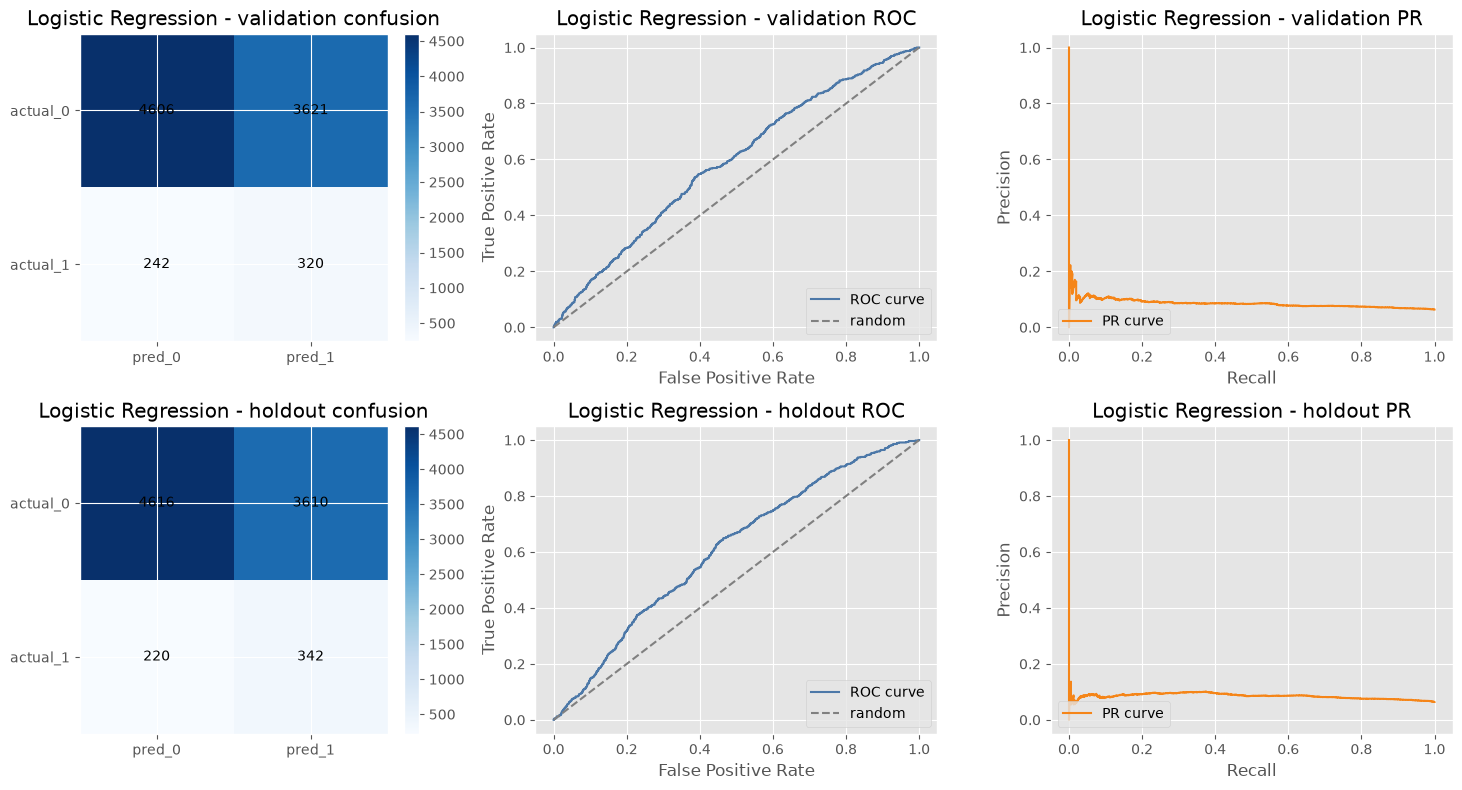

In [6]:
plot_result_diagnostics(logistic_result, 'Logistic Regression')

**Interpretation:** Logistic Regression is the cleanest explainable baseline and preserves a reasonable claim-capture rate, but it underfits the nonlinear interactions in this portfolio. It produces the weakest ROC-AUC and PR-AUC of the evaluated classical models and generates many false positives at the default threshold.

## Phase 3 - Decision Tree

In [7]:
decision_tree_result = benchmark_results['decision_tree']
print_model_summary(decision_tree_result)

Selection rule: Rank by validation PR-AUC, then ROC-AUC, then recall, then F1.
Best hyperparameters: {'max_depth': 4, 'min_samples_split': 200, 'min_samples_leaf': 100, 'class_weight': 'balanced', 'random_state': 42}


,split,accuracy,precision,recall,f1,roc_auc,pr_auc
0,validation,0.541586,0.088340,0.661922,0.155877,0.628703,0.118420
1,holdout,0.546427,0.091213,0.679715,0.160842,0.649624,0.134058


,candidate_id,model,hyperparameters,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_pr_auc
0,1,Decision Tree,"{""class_weight"": ""balanced"", ""max_depth"": 4, ""...",0.541586,0.088340,0.661922,0.155877,0.628703,0.118420
1,6,Decision Tree,"{""class_weight"": ""balanced"", ""max_depth"": null...",0.564911,0.089376,0.631673,0.156595,0.626067,0.114128
2,2,Decision Tree,"{""class_weight"": ""balanced"", ""max_depth"": 6, ""...",0.521675,0.087823,0.690391,0.155823,0.634511,0.102967
3,4,Decision Tree,"{""class_weight"": ""balanced"", ""max_depth"": 10, ...",0.520196,0.084376,0.660142,0.149627,0.625503,0.102082
4,5,Decision Tree,"{""class_weight"": ""balanced"", ""max_depth"": 12, ...",0.573444,0.087497,0.601423,0.152768,0.622649,0.101869
5,3,Decision Tree,"{""class_weight"": ""balanced"", ""max_depth"": 8, ""...",0.490955,0.084184,0.704626,0.150399,0.621176,0.097526


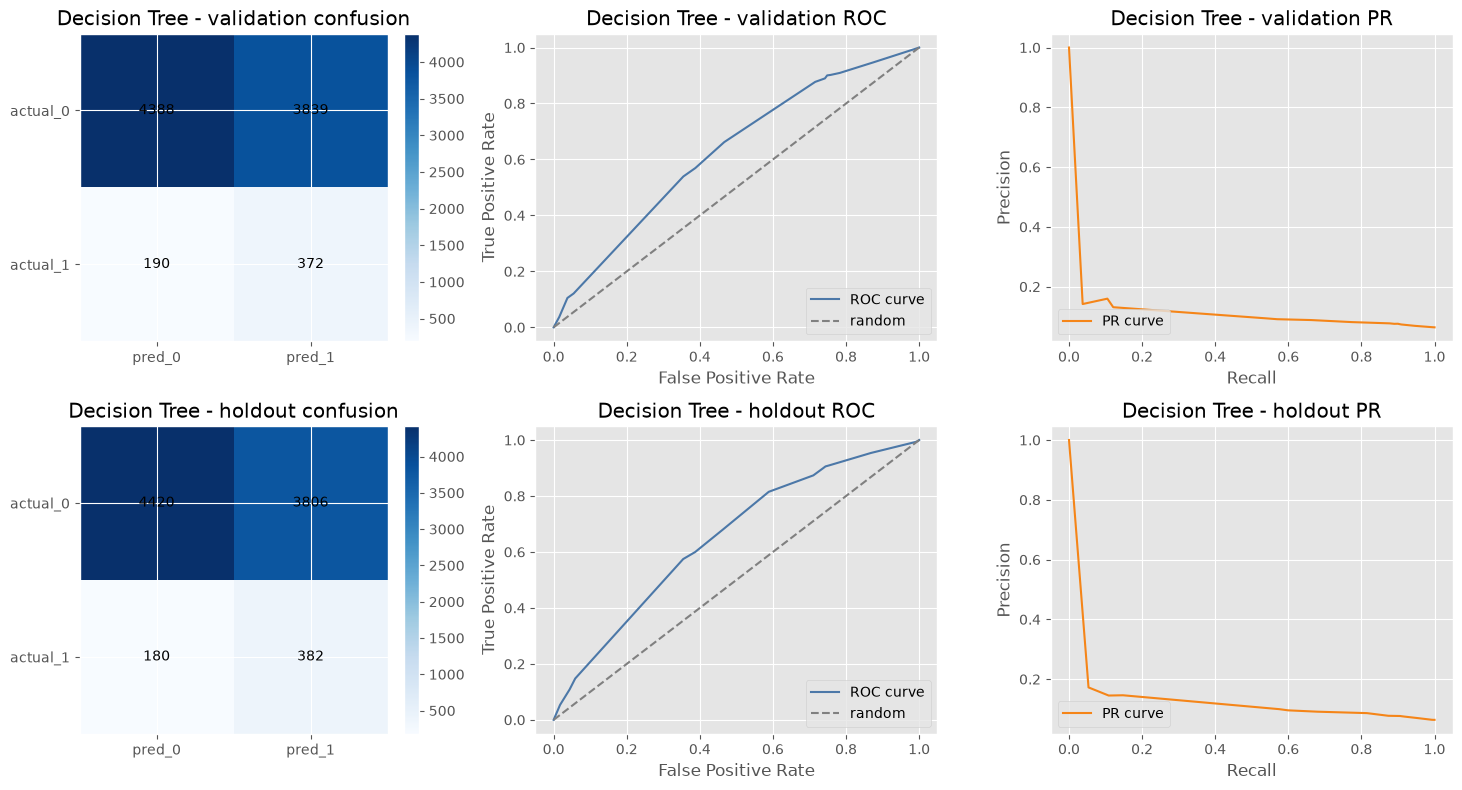

In [8]:
plot_result_diagnostics(decision_tree_result, 'Decision Tree')

**Interpretation:** The selected shallow decision tree is the strongest high-recall classical model in this sprint. It wins holdout recall and PR-AUC, which makes it attractive for underwriting triage, but it still trades that recall for a large false-positive burden and less stable ranking quality than the Random Forest.

## Phase 4 - Random Forest

In [9]:
random_forest_result = benchmark_results['random_forest']
print_model_summary(random_forest_result)

Selection rule: Rank by validation PR-AUC, then ROC-AUC, then recall, then F1.
Best hyperparameters: {'n_estimators': 200, 'max_depth': 8, 'min_samples_split': 200, 'min_samples_leaf': 50, 'class_weight': 'balanced_subsample', 'n_jobs': -1, 'random_state': 42}


,split,accuracy,precision,recall,f1,roc_auc,pr_auc
0,validation,0.581750,0.091981,0.624555,0.160347,0.637209,0.104989
1,holdout,0.590692,0.096302,0.644128,0.167554,0.662448,0.110513


,candidate_id,model,hyperparameters,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_pr_auc
0,1,Random Forest,"{""class_weight"": ""balanced_subsample"", ""max_de...",0.581750,0.091981,0.624555,0.160347,0.637209,0.104989
1,2,Random Forest,"{""class_weight"": ""balanced_subsample"", ""max_de...",0.627261,0.094925,0.565836,0.162577,0.633012,0.101885
2,3,Random Forest,"{""class_weight"": ""balanced_subsample"", ""max_de...",0.635340,0.096735,0.564057,0.165147,0.633309,0.101593
3,6,Random Forest,"{""class_weight"": ""balanced_subsample"", ""max_de...",0.614063,0.094556,0.587189,0.162883,0.633807,0.101020
4,5,Random Forest,"{""class_weight"": ""balanced_subsample"", ""max_de...",0.631926,0.095857,0.564057,0.163867,0.633077,0.100194
5,4,Random Forest,"{""class_weight"": ""balanced_subsample"", ""max_de...",0.675503,0.095977,0.483986,0.160188,0.627537,0.099444


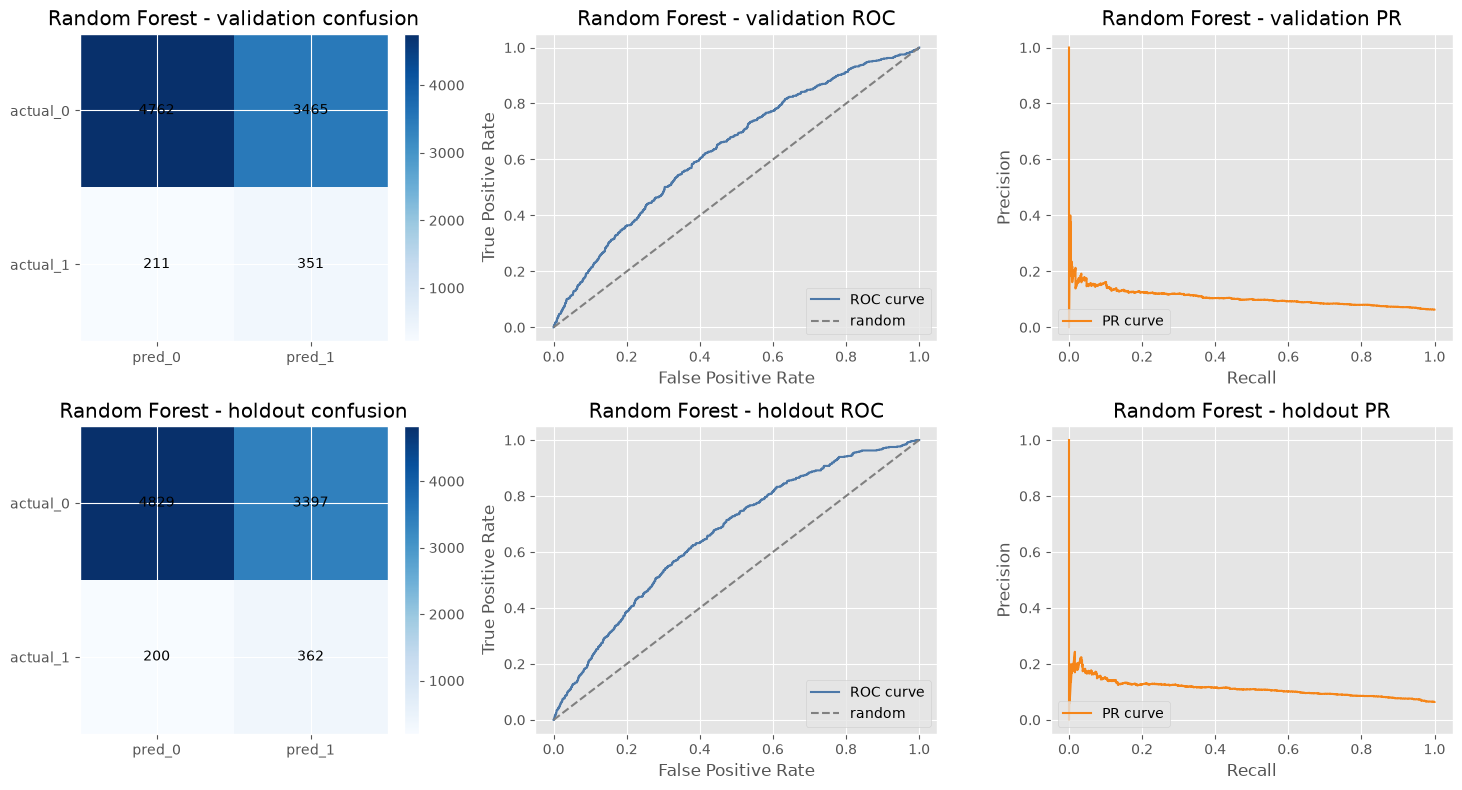

In [10]:
plot_result_diagnostics(random_forest_result, 'Random Forest')

,feature,importance,importance_type
0,policy_tenure,0.375892,tree_importance
1,age_of_car,0.257566,tree_importance
2,age_of_policyholder,0.098670,tree_importance
3,population_density,0.071569,tree_importance
4,area_cluster__freq,0.068193,tree_importance
5,vehicle_volume_proxy,0.009277,tree_importance
6,engine_type__freq,0.008052,tree_importance
7,power_bhp,0.007425,tree_importance
8,power_to_weight,0.007410,tree_importance
9,model__freq,0.006874,tree_importance


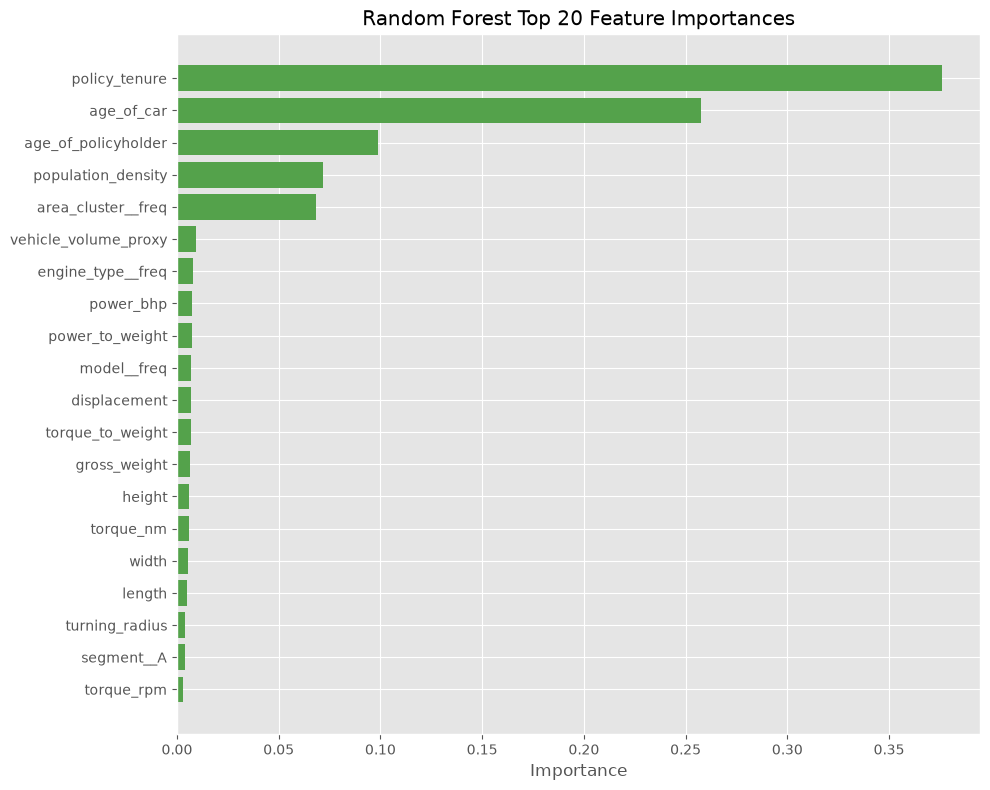

In [11]:
rf_importance = eng.feature_importance_table(random_forest_result['best_model'], dataset.feature_names, top_n=20)
display(rf_importance)

fig, ax = plt.subplots(figsize=(10, 8))
eng.plot_feature_importance(rf_importance, ax, 'Random Forest Top 20 Feature Importances')
plt.tight_layout()

**Interpretation:** Random Forest delivers the best overall ranking quality on the frozen Sprint 3 data. It wins holdout ROC-AUC, precision, F1, and accuracy among the evaluated classical models while keeping recall competitive. The tradeoff is interpretability: it is more explainable than a neural model, but less transparent than Logistic Regression or a single shallow tree.

## Phase 5 - XGBoost

In [12]:
xgboost_result = benchmark_results['xgboost']
if xgboost_result.get('status') == 'skipped':
    print('XGBoost skipped:', xgboost_result['reason'])
else:
    print_model_summary(xgboost_result)
    plot_result_diagnostics(xgboost_result, 'XGBoost')

XGBoost skipped: xgboost is not installed in the local environment.


## Phase 6 - Model Comparison

In [13]:
display(validation_comparison)
display(holdout_comparison)
display(eng.model_ranking_table(holdout_comparison))
display(eng.model_leaderboard_summary(holdout_comparison))

,model,status,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,Evaluated,0.560473,0.081198,0.569395,0.142127,0.589179,0.085115
1,Decision Tree,Evaluated,0.541586,0.088340,0.661922,0.155877,0.628703,0.118420
2,Random Forest,Evaluated,0.581750,0.091981,0.624555,0.160347,0.637209,0.104989
3,XGBoost,Skipped: xgboost is not installed in the local...,NaN,NaN,NaN,NaN,NaN,NaN


,model,status,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,Evaluated,0.564178,0.086538,0.608541,0.151529,0.609487,0.084656
1,Decision Tree,Evaluated,0.546427,0.091213,0.679715,0.160842,0.649624,0.134058
2,Random Forest,Evaluated,0.590692,0.096302,0.644128,0.167554,0.662448,0.110513
3,XGBoost,Skipped: xgboost is not installed in the local...,NaN,NaN,NaN,NaN,NaN,NaN


,rank,model,status,accuracy,precision,recall,f1,roc_auc,pr_auc
0,1,Decision Tree,Evaluated,0.546427,0.091213,0.679715,0.160842,0.649624,0.134058
1,2,Random Forest,Evaluated,0.590692,0.096302,0.644128,0.167554,0.662448,0.110513
2,3,Logistic Regression,Evaluated,0.564178,0.086538,0.608541,0.151529,0.609487,0.084656


,category,model
0,Best ROC-AUC,Random Forest
1,Best Recall,Decision Tree
2,Best Precision,Random Forest
3,Best PR-AUC,Decision Tree
4,Most Explainable Model,Logistic Regression


## Phase 7 - Business Interpretation

In [14]:
best_model_result = random_forest_result
risk_summary = eng.risk_segment_summary(best_model_result['best_model'], dataset.X_holdout, dataset.y_holdout)
domain_summary = eng.domain_feature_summary(risk_summary['feature_deltas'], top_n=12)

display(risk_summary['risk_band_summary'])
display(domain_summary)

higher_risk_features = risk_summary['feature_deltas'][risk_summary['feature_deltas']['difference'] > 0].head(12)
lower_risk_features = risk_summary['feature_deltas'][risk_summary['feature_deltas']['difference'] < 0].head(12)

print('Higher-risk feature patterns:')
display(higher_risk_features)
print('Lower-risk feature patterns:')
display(lower_risk_features)

,risk_band,rows,average_predicted_probability,actual_claim_rate
0,top_decile,879,0.616265,0.126280
1,bottom_decile,879,0.274377,0.021615


,feature,high_risk_mean,low_risk_mean,difference,abs_difference,domain
0,policy_tenure,0.164011,-1.226059,1.390069,1.390069,policy
1,age_of_car,-0.822993,-0.086220,-0.736773,0.736773,vehicle_profile
2,height,-0.543840,0.133536,-0.677377,0.677377,vehicle_profile
3,age_of_policyholder,0.374426,-0.248772,0.623198,0.623198,policy
4,gear_box,-0.523297,0.039508,-0.562805,0.562805,vehicle_profile
5,gross_weight,-0.557525,-0.027393,-0.530131,0.530131,vehicle_profile
6,vehicle_volume_proxy,-0.660711,-0.138951,-0.521759,0.521759,vehicle_profile
7,airbags,-0.554301,-0.034440,-0.519860,0.519860,safety
8,turning_radius,-0.632601,-0.121898,-0.510703,0.510703,vehicle_profile
9,power_rpm,0.490633,-0.004394,0.495027,0.495027,vehicle_profile


Higher-risk feature patterns:


,feature,high_risk_mean,low_risk_mean,difference,abs_difference
0,policy_tenure,0.164011,-1.226059,1.390069,1.390069
3,age_of_policyholder,0.374426,-0.248772,0.623198,0.623198
9,power_rpm,0.490633,-0.004394,0.495027,0.495027
16,torque_rpm,0.216332,-0.167072,0.383404,0.383404
19,area_cluster__freq,0.011944,-0.350905,0.362848,0.362848
22,transmission_type__Manual,0.943117,0.673493,0.269625,0.269625
26,engine_type__freq,0.251310,0.010726,0.240584,0.240584
27,model__freq,0.251310,0.010726,0.240584,0.240584
28,make__1,0.902162,0.664391,0.237770,0.237770
31,rear_brakes_type__Drum,0.979522,0.747440,0.232082,0.232082


Lower-risk feature patterns:


,feature,high_risk_mean,low_risk_mean,difference,abs_difference
1,age_of_car,-0.822993,-0.086220,-0.736773,0.736773
2,height,-0.543840,0.133536,-0.677377,0.677377
4,gear_box,-0.523297,0.039508,-0.562805,0.562805
5,gross_weight,-0.557525,-0.027393,-0.530131,0.530131
6,vehicle_volume_proxy,-0.660711,-0.138951,-0.521759,0.521759
7,airbags,-0.554301,-0.034440,-0.519860,0.519860
8,turning_radius,-0.632601,-0.121898,-0.510703,0.510703
10,parking_assist_score,-0.568491,-0.079400,-0.489091,0.489091
11,length,-0.655604,-0.181977,-0.473627,0.473627
12,torque_nm,-0.574680,-0.114233,-0.460446,0.460446


For insurance agents and underwriters, the strongest Random Forest signals suggest that higher predicted claim probability is concentrated in policies with longer tenure, older policyholders, more manual and lower-spec vehicle configurations, and weaker safety-support proxies. Lower predicted risk is associated with larger or heavier vehicles, stronger safety signals such as airbags and NCAP-related support, automatic transmission, and richer parking/safety equipment.

One important nuance is `age_of_car`: in this frozen benchmark, the higher-risk decile skews toward a lower standardized `age_of_car` value, which means newer cars relative to the training mean. That should be treated as a portfolio pattern to investigate, not a direct causal rule.

## Phase 8 - Sprint Recommendation

In [15]:
recommendation_table = pd.DataFrame([
    {
        'decision': 'Baseline production candidate',
        'recommendation': 'Random Forest',
        'reason': 'Best holdout ROC-AUC, best precision, best F1, and the strongest overall balance across ranking and threshold metrics.'
    },
    {
        'decision': 'Primary model to compare against PyTorch in Sprint 5',
        'recommendation': 'Random Forest',
        'reason': 'It is the strongest overall classical challenger on the frozen Sprint 3 dataset.'
    },
    {
        'decision': 'Expected PyTorch strengths',
        'recommendation': 'Higher-order interaction learning and smoother probability ranking',
        'reason': 'A neural model may improve ROC-AUC and PR-AUC if the portfolio contains nonlinear cross-feature effects that trees and logistic regression only capture partially.'
    },
    {
        'decision': 'Expected PyTorch risks',
        'recommendation': 'Overfitting, longer tuning cycles, and weaker explainability',
        'reason': 'The tabular signal is modest, so neural complexity may add variance faster than it adds lift without careful regularization and calibration.'
    },
])
display(recommendation_table)

,decision,recommendation,reason
0,Baseline production candidate,Random Forest,"Best holdout ROC-AUC, best precision, best F1,..."
1,Primary model to compare against PyTorch in Sp...,Random Forest,It is the strongest overall classical challeng...
2,Expected PyTorch strengths,Higher-order interaction learning and smoother...,A neural model may improve ROC-AUC and PR-AUC ...
3,Expected PyTorch risks,"Overfitting, longer tuning cycles, and weaker ...","The tabular signal is modest, so neural comple..."


Sprint 4 stops here. No PyTorch models were built, and Sprint 5 was not started.